In [ ]:
import os
import sys

# ノートブックがあるディレクトリからプロジェクトのルートパスを取得
# （例：/project_name/notebooks/から/project_name/を取得）
project_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

# srcディレクトリへのパスをPythonのモジュール探索パスに追加
src_path = os.path.join(project_path, 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

# 探索パスが正しく設定されたか確認
print(sys.path)

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from model import VQVAE, MLP
import yaml
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
import umap
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
import itertools
import pandas as pd

['/root/.pyenv/versions/3.11.9/lib/python311.zip', '/root/.pyenv/versions/3.11.9/lib/python3.11', '/root/.pyenv/versions/3.11.9/lib/python3.11/lib-dynload', '', '/root/.pyenv/versions/3.11.9/lib/python3.11/site-packages', '/workspace/inhouse-vqvae/VQVAE/src']


ModuleNotFoundError: No module named 'torch'

## ハイパラ指定  
data_root_dir データのディレクトリ

In [ ]:
data_root_dir = "/workspace/inhouse-vqvae/VQVAE/model/No-shuffle/tgtaa_vahadane4"
codebook_size = 256

In [1]:
mda_patho_check_list = ['63431', '63433', '63435', '63438', '63442', '63446', '63450', '63466', '63473', '63477', '63481', '63485', '63489', '63494', '63497', '63501', '63505', '63509', '63513', '63517', '63522', '63526', '63530', '63534', '63538', '63542', '63546', '63550', '63553', '63558', '63562', '63566', '63571', '63575', '63579', '63583', '63587', '63591', '63595', '63598', '63602', '63605', '63609', '63612', '63616', '63620', '63623', '63665', '63669', '63672', '63676', '63680', '63748', '63752', '63756', '63831', '63937', '63684', '63687', '63691', '70929', '63698', '63760', '63763', '63768', '63772', '63777', '63855', '63860', '63865', '71285', '63875', '63941', '63944', '63948', '63952', '63955']
taa_patho_check_list = ['27622', '27624', '27626', '27628', '27630', '27632', '27634', '27636', '27638', '27640', '27642', '27644', '27646', '27651', '27655', '27657', '27660', '27662', '27663', '27665', '27668', '27670', '27672', '27674', '27676', '27678', '27680', '27682', '27684', '27686', '27689', '46720', '46727', '46736', '46740', '46744', '46747', '46750', '46753', '46756', '46758', '46759', '46763', '46765', '46768', '46769', '46772', '46774', '46778', '46781', '46783', '46787', '46789', '46792', '46795', '46797', '46800', '46803', '46806', '46809', '46811', '46815', '46817', '46820', '46823', '46826', '46829', '46831', '46833', '46835', '46839', '46841', '46844']
min(mda_patho_check_list)

'63431'

In [3]:
# データを一時的に格納するリスト
all_data_list = []
n_columns_list = []
pathological_list = []

# ファイル名が降順になるようにソートをかけている
# 必ずしも必要ではないが理解のために一応の処置
files = os.listdir(data_root_dir)
sorted_files = sorted(files)

for filename in sorted_files:
    if not filename.lower().endswith("idx.pt"):
        # 余分なファイルを生成したりしているので分岐をかけている、保存するディレクトリ分けた方がいい
        data_path = os.path.join(data_root_dir, filename)
        part_data = torch.load(data_path).cpu()
        all_data_list.append(part_data)
        n_columns_list.append(part_data.size()[0])

        base_filename = os.path.splitext(filename)[0]
        if base_filename in mda_patho_check_list:
            pathological_list.append(1)
        elif base_filename in taa_patho_check_list:
            pathological_list.append(3)
        elif int(base_filename) < 47000:
            pathological_list.append(2)
        else:
            pathological_list.append(0)

# ループ終了後、一度に結合
if all_data_list:  # リストが空でないことを確認
    usages = torch.cat(all_data_list, 0)
    print("結合されたテンソルのサイズ:", usages.size())
else:
    print("読み込むべきデータファイルが見つかりませんでした。")

print(pathological_list)
usages_scaled = usages / 1024 / (256/torch.count_nonzero(usages[0]))

NameError: name 'os' is not defined

In [ ]:
print(sum(n_columns_list[:159]))

0


In [ ]:
usages[0]

NameError: name 'usages' is not defined

In [ ]:
print("PCAによる次元削減と可視化を実行中...")
scaler = StandardScaler()
data_scaled = scaler.fit_transform(usages)


pca = PCA(n_components=8)
X_pca = pca.fit_transform(data_scaled)

color_list = []
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',]
for i in range(len(n_columns_list)):
    for j in range(n_columns_list[i]):
        color_list.append(colors[i % 8])

# 結果の可視化
plt.figure(figsize=(10, 8))
# c引数に色の配列を指定
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color_list, alpha=0.8, s=5)

plt.title('Dimensionality reduction to two dimensions using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

print("PCAの処理が完了しました。")

PCAによる次元削減と可視化を実行中...


NameError: name 'StandardScaler' is not defined

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(pca.explained_variance_ratio_, marker='o', linestyle='-')

plt.title('Basic Line Plot (Index on X-axis)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.yscale('log')
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [8]:

component_weights = pca.components_

plt.figure(figsize=(10, 6))

# ヒストグラムの作成
# bins='auto' は最適なビンの数を自動的に計算します
plt.hist(component_weights[3], bins='auto', edgecolor='black', alpha=0.7)
print(component_weights[3])

# タイトルと軸ラベルの設定
plt.title('Distribution of Numerical Array (Histogram)', fontsize=16)
plt.xlabel('Value', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', alpha=0.5)

# グラフの表示範囲を調整 (必要に応じて)
# plt.xlim(-4, 4)

max(component_weights[0])
# # 重みをDataFrameに変換して見やすくする
# component_df = pd.DataFrame(
#     component_weights,
#     index=['PC1', 'PC2'],
#     columns=usages.columns
# )

# print(component_df)

NameError: name 'pca' is not defined

In [9]:
print("PCAによる次元削減と可視化を実行中...")
scaler = StandardScaler()
data_scaled = scaler.fit_transform(usages)


pca = PCA(n_components=4)
X_pca = pca.fit_transform(data_scaled)

color_list = []
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i in range(len(n_columns_list)):
    for j in range(n_columns_list[i]):
        color_list.append(colors[pathological_list[i]])

# 結果の可視化
plt.figure(figsize=(10, 8))
# c引数に色の配列を指定
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color_list, alpha=0.5, s=5)

plt.title('Dimensionality reduction to two dimensions using PCA')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.grid(True)
plt.show()

print("PCAの処理が完了しました。")

PCAによる次元削減と可視化を実行中...


NameError: name 'StandardScaler' is not defined

In [10]:
n_components = 5

scaler = StandardScaler()
data_scaled = scaler.fit_transform(usages)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(data_scaled)

color_list = []
colors = ['#1f77b4', "#011480", '#2ca02c', "#004600",
          '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
for i in range(len(n_columns_list)):
    for j in range(n_columns_list[i]):
        color_list.append(colors[pathological_list[i]])

fig, axes = plt.subplots(dpi=400, nrows=n_components-1, ncols=n_components-1, figsize=(15, 15))
elements = range(0, n_components)
all_comnbinations = itertools.combinations(elements, 2)

for combo in all_comnbinations:
    axes[combo[0], combo[1]-1].scatter(X_pca[:, combo[0]], X_pca[:, combo[1]], c=color_list[:], alpha=0.5, s=5)
    axes[combo[0], combo[1]-1].set_title(f'combination = {combo}')
    axes[combo[0], combo[1]-1].grid(True)

NameError: name 'StandardScaler' is not defined

UMAPによる次元削減と可視化を実行中...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


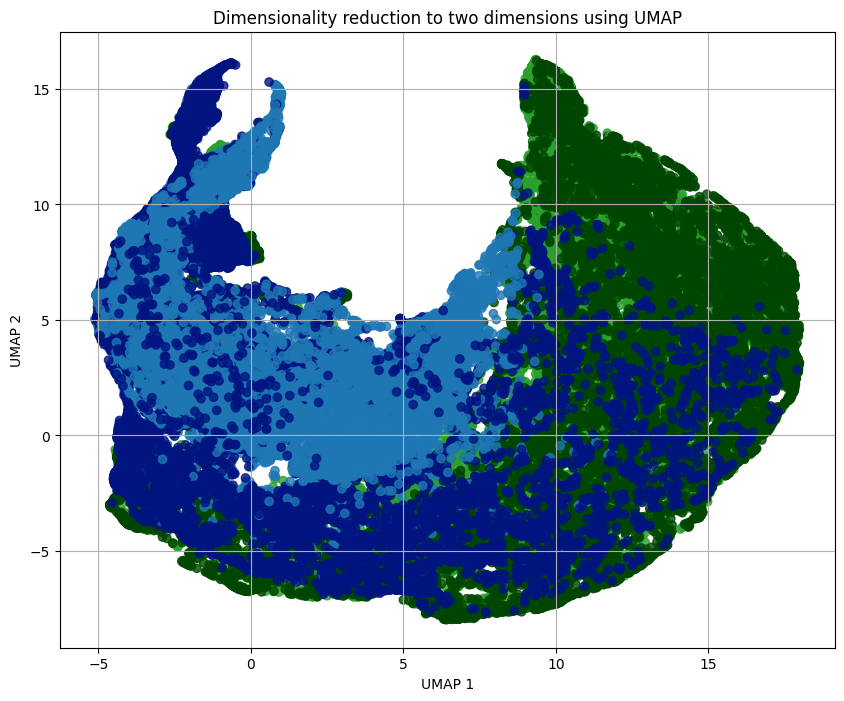

UMAPの処理が完了しました。


In [30]:
# --- UMAPによる次元削減と可視化 ---
print("UMAPによる次元削減と可視化を実行中...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(usages_scaled)

# 結果の可視化
plt.figure(figsize=(10, 8))
# c引数に色の配列を指定
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=color_list, alpha=0.8)

# 凡例の作成
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10) for c in colors]

plt.title('Dimensionality reduction to two dimensions using UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

print("UMAPの処理が完了しました。")

UMAPによる次元削減と可視化を実行中...


/opt/patho/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


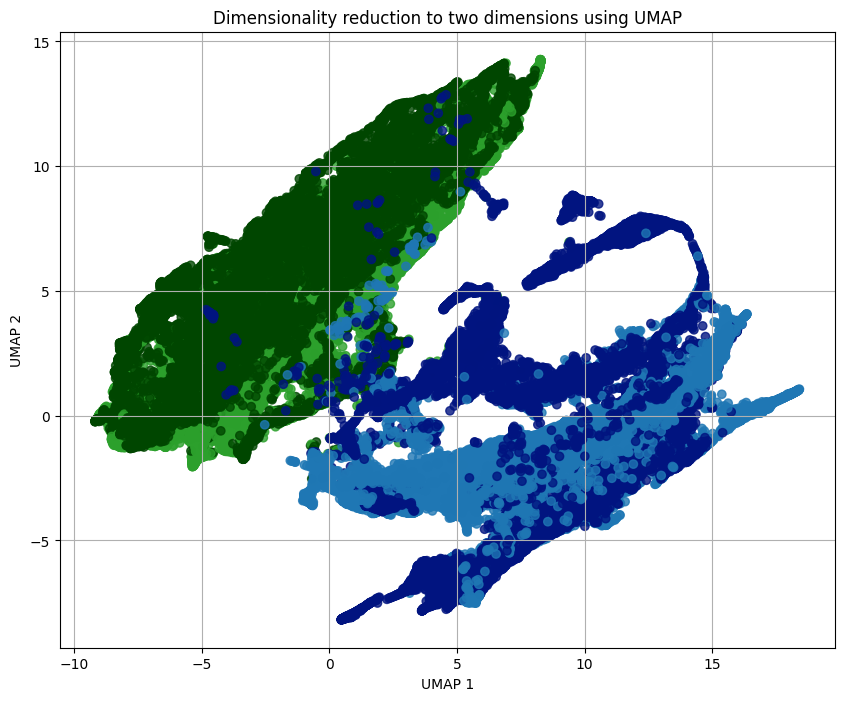

UMAPの処理が完了しました。


In [19]:
# --- UMAPによる次元削減と可視化 ---
print("UMAPによる次元削減と可視化を実行中...")
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(usages_scaled)

# 結果の可視化
plt.figure(figsize=(10, 8))
# c引数に色の配列を指定
scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=color_list, alpha=0.8)

# 凡例の作成
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10) for c in colors]

plt.title('Dimensionality reduction to two dimensions using UMAP')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

print("UMAPの処理が完了しました。")